# Algoritmo de clasificacion KNN

Nelson Escalante - 22046

Este archivo incluye los incisos del 4 al 5 de la seccion de actividades.

### SETUP

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

train_path = "../data/train.csv"
train = pd.read_csv(train_path)

### INCISO 4:

Creacion del modelo de clasificacion utilizando KNN

In [4]:
p33 = train["SalePrice"].quantile(0.33)
p66 = train["SalePrice"].quantile(0.66)

print(f"Límite Económicas: Menos de ${p33:,.0f}")
print(f"Límite Intermedias: Entre ${p33:,.0f} y ${p66:,.0f}")
print(f"Límite Caras: Más de ${p66:,.0f}")

Límite Económicas: Menos de $139,000
Límite Intermedias: Entre $139,000 y $189,893
Límite Caras: Más de $189,893


In [5]:
def categorize_price(price):
    if price <= p33:
        return "Económica"
    elif price <= p66:
        return "Intermedia"
    else:
        return "Cara"

# Aplicar la función a la columna SalePrice
train["PriceCategory"] = train["SalePrice"].apply(categorize_price)

# Verificar distribución de clases
train["PriceCategory"].value_counts()

PriceCategory
Cara          497
Económica     483
Intermedia    480
Name: count, dtype: int64

Modelo de clasificacion KNN

In [6]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=["SalePrice", "PriceCategory"])  
y = train["PriceCategory"]  # Variable objetivo

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Escalado de datos

In [7]:
print("Valores nulos en entrenamiento:", X_train.isnull().sum().sum())
print("Valores nulos en prueba:", X_test.isnull().sum().sum())


Valores nulos en entrenamiento: 247
Valores nulos en prueba: 101


In [8]:
# Rellenar numéricos con la mediana
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())  # importante: usar la mediana de entrenamiento

X_train = X_train.fillna("Desconocido")
X_test = X_test.fillna("Desconocido")

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Crear y entrenar el modelo
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predecir
y_pred_knn = knn.predict(X_test_scaled)

# Evaluar precisión
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Precisión del modelo KNN (k=5): {accuracy_knn:.2%}")
print("\n Reporte de clasificación:")
print(classification_report(y_test, y_pred_knn))


Precisión del modelo KNN (k=5): 74.66%

 Reporte de clasificación:
              precision    recall  f1-score   support

        Cara       0.82      0.80      0.81       142
   Económica       0.75      0.90      0.82       155
  Intermedia       0.66      0.53      0.59       141

    accuracy                           0.75       438
   macro avg       0.74      0.74      0.74       438
weighted avg       0.74      0.75      0.74       438



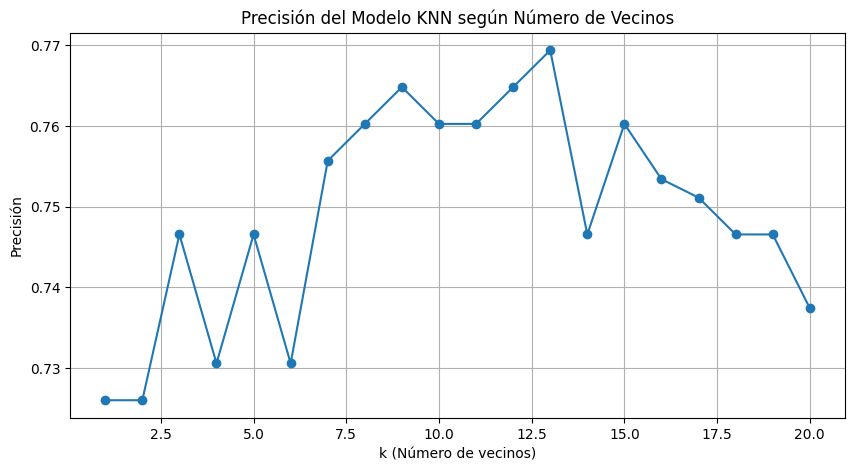

In [11]:
import matplotlib.pyplot as plt

scores = []
k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    scores.append(acc)

# Visualizar resultados
plt.figure(figsize=(10, 5))
plt.plot(k_values, scores, marker='o')
plt.title("Precisión del Modelo KNN según Número de Vecinos")
plt.xlabel("k (Número de vecinos)")
plt.ylabel("Precisión")
plt.grid(True)
plt.show()


Mejor k: 13, Precisión: 76.94%


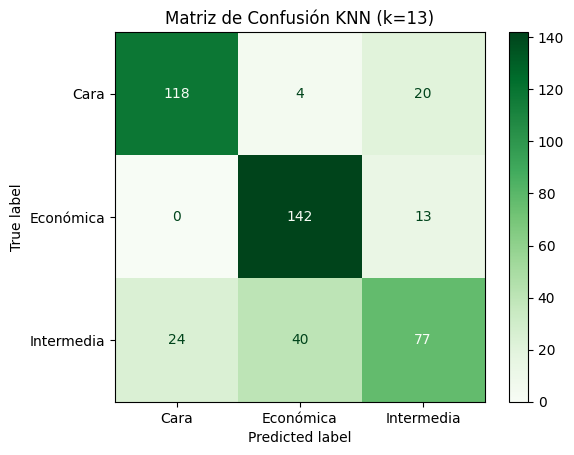

In [12]:
best_k = k_values[scores.index(max(scores))]
print(f"Mejor k: {best_k}, Precisión: {max(scores):.2%}")

# Modelo final
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_final = knn_final.predict(X_test_scaled)

# Evaluar con matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_knn = confusion_matrix(y_test, y_pred_final, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=knn.classes_)
disp.plot(cmap="Greens", values_format="d")
plt.title(f"Matriz de Confusión KNN (k={best_k})")
plt.show()


Se realizo un entrenamiento de un modelo KNN para la clasificacion de los precios de las casas, para el cual se probaron valores k entre 1 y 20. Durante las pruebas se encontro que el modelo con la mayor precision se encontraba en k=13, con una precision del 76.94%.

Observando la matriz de confusion nos damos cuenta que, al igual que con otros algoritmos de clasificacion, la mayor parte de las confusiones se realizan entre los precios de las casas intermedias y los dos extremos que la rodean. Este tipo de error es esperable, y aun asi el algoritmo realiza un buen trabajo clasificando los precios de las casas.

In [13]:
from sklearn.metrics import accuracy_score

# Predicción en entrenamiento y prueba
y_train_pred = knn_final.predict(X_train_scaled)
y_test_pred = knn_final.predict(X_test_scaled)

# Calcular precisión
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Precisión en entrenamiento: {train_acc:.2%}")
print(f"Precisión en prueba: {test_acc:.2%}")

Precisión en entrenamiento: 77.79%
Precisión en prueba: 76.94%


Al evaluar la precision en los conjuntos de entrenamiento y de prueba podemos observar que la diferencia entre ambas precisiones es muy baja, lo que es buen indicador para asegurar que el modelo no indica sobreajuste.

Este modelo es capaz de generalizar de buena manera los datos que se encuentran en el conjunto, por lo que puede ser bastante util para realizar predicciones de los precios de las casas.